## 1. Setup — imports, versions, and configuration
Load the libraries, confirm this kernel is the upgraded one (scikit-learn 1.9.0), and set the file paths and column names in one place so later cells never hard-code them.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)   # show all columns, never truncate

# --- library versions (confirms the kernel is the one we just upgraded) ---
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("seaborn:", sns.__version__)
print("sklearn:", sklearn.__version__)

# --- config: single source of truth ---
# r"..." = "raw string" so Windows backslashes are taken literally, not as escape codes
FEATURES_DIR = r"C:\tpot-project\04-features"
BEHAV_PATH   = FEATURES_DIR + r"\dataset_behavioral.csv"
FULL_PATH    = FEATURES_DIR + r"\dataset_full.csv"

ID_COL    = "run_id"   # names the row (D001, S014...) — NOT a feature the model may use
LABEL_COL = "label"    # the answer we want to predict

# fixed class order so every table and plot lists the classes the same way
CLASS_ORDER = ["scan", "brute_force", "post_exploitation", "web_attack", "denial_of_service"]

RANDOM_STATE = 42      # not used yet; kept here so modeling cells later share one value

pandas : 2.3.3
numpy  : 2.3.5
seaborn: 0.13.2
sklearn: 1.9.0


## 2. Load both datasets
Read the two CSV files into pandas tables (`df_behav`, `df_full`) and confirm each has 150 rows.

In [2]:
# read the two CSV files into pandas DataFrames (a DataFrame is a table: rows x columns)
df_behav = pd.read_csv(BEHAV_PATH)
df_full  = pd.read_csv(FULL_PATH)

# .shape is (number_of_rows, number_of_columns)
print("behavioral :", df_behav.shape, " (rows, columns)")
print("full       :", df_full.shape,  " (rows, columns)")
print()
print("behavioral rows:", len(df_behav))
print("full rows      :", len(df_full))

behavioral : (150, 36)  (rows, columns)
full       : (150, 45)  (rows, columns)

behavioral rows: 150
full rows      : 150


## 3. First look at the raw data
Show the first few rows and the column list with data types, so we can eyeball that everything loaded correctly.

In [3]:
# .head() shows the first 5 rows — so we can see what the data actually contains
print("=== behavioral — first 5 rows ===")
display(df_behav.head())

print("=== full — first 5 rows ===")
display(df_full.head())

# .info() lists every column, its data type, and how many non-empty values it has
print("\n=== behavioral — column info ===")
df_behav.info()

print("\n=== full — column info ===")
df_full.info()

=== behavioral — first 5 rows ===


,run_id,label,total_events,duration_sec,events_per_sec,inter_event_mean,inter_event_std,burst_max_per_sec,burstiness,distinct_dest_ports,distinct_src_ports,ports_per_event,frac_on_top_port,distinct_protocols,n_login_fail,n_login_success,n_commands,n_command_failed,n_sessions,n_file_downloads,distinct_commands,n_auth_other,n_http_events,n_web_80,n_web_8080,distinct_web_paths,n_suricata_alerts,n_suricata_flows,n_alert_sev_high,n_alert_sev_info,distinct_signatures,any_login_attempt,any_login_success,any_command_run,any_file_download,any_web_request
0,B001,brute_force,56,1.0,56.0000,0.0182,0.1336,53,1.893,1,5,0.01786,1.0,2,3,1,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
1,B002,brute_force,82,7.0,11.7143,0.0864,0.2810,47,4.585,1,10,0.01220,1.0,2,23,1,0,0,5,0,0,0,0,0,0,0,0,5,0,0,0,1,1,0,0,0
2,B003,brute_force,68,6.0,11.3333,0.0896,0.4136,53,3.897,1,9,0.01471,1.0,2,11,1,0,0,5,0,0,0,0,0,0,0,0,4,0,0,0,1,1,0,0,0
3,B004,brute_force,518,21.0,24.6667,0.0406,0.1974,62,2.633,1,46,0.00193,1.0,2,75,1,0,0,41,0,0,0,0,0,0,0,1,5,0,1,1,1,1,0,0,0
4,B005,brute_force,694,67.0,10.3582,0.0967,0.3098,51,4.850,1,54,0.00144,1.0,2,248,1,0,0,41,0,0,0,0,0,0,0,0,14,0,0,0,1,1,0,0,0


=== full — first 5 rows ===


,run_id,label,total_events,duration_sec,events_per_sec,inter_event_mean,inter_event_std,burst_max_per_sec,burstiness,distinct_dest_ports,distinct_src_ports,ports_per_event,frac_on_top_port,distinct_protocols,n_login_fail,n_login_success,n_commands,n_command_failed,n_sessions,n_file_downloads,distinct_commands,n_auth_other,n_http_events,n_web_80,n_web_8080,distinct_web_paths,n_suricata_alerts,n_suricata_flows,n_alert_sev_high,n_alert_sev_info,distinct_signatures,any_login_attempt,any_login_success,any_command_run,any_file_download,any_web_request,n_p0f,n_suricata,n_cowrie,n_dionaea,n_honeytrap,n_heralding,n_tanner,n_fatt,n_wordpot
0,B001,brute_force,56,1.0,56.0000,0.0182,0.1336,53,1.893,1,5,0.01786,1.0,2,3,1,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,22,5,24,0,0,0,0,5,0
1,B002,brute_force,82,7.0,11.7143,0.0864,0.2810,47,4.585,1,10,0.01220,1.0,2,23,1,0,0,5,0,0,0,0,0,0,0,0,5,0,0,0,1,1,0,0,0,23,10,44,0,0,0,0,5,0
2,B003,brute_force,68,6.0,11.3333,0.0896,0.4136,53,3.897,1,9,0.01471,1.0,2,11,1,0,0,5,0,0,0,0,0,0,0,0,4,0,0,0,1,1,0,0,0,22,9,32,0,0,0,0,5,0
3,B004,brute_force,518,21.0,24.6667,0.0406,0.1974,62,2.633,1,46,0.00193,1.0,2,75,1,0,0,41,0,0,0,0,0,0,0,1,5,0,1,1,1,1,0,0,0,190,47,240,0,0,0,0,41,0
4,B005,brute_force,694,67.0,10.3582,0.0967,0.3098,51,4.850,1,54,0.00144,1.0,2,248,1,0,0,41,0,0,0,0,0,0,0,0,14,0,0,0,1,1,0,0,0,185,55,413,0,0,0,0,41,0



=== behavioral — column info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   run_id               150 non-null    object 
 1   label                150 non-null    object 
 2   total_events         150 non-null    int64  
 3   duration_sec         150 non-null    float64
 4   events_per_sec       150 non-null    float64
 5   inter_event_mean     150 non-null    float64
 6   inter_event_std      150 non-null    float64
 7   burst_max_per_sec    150 non-null    int64  
 8   burstiness           150 non-null    float64
 9   distinct_dest_ports  150 non-null    int64  
 10  distinct_src_ports   150 non-null    int64  
 11  ports_per_event      150 non-null    float64
 12  frac_on_top_port     150 non-null    float64
 13  distinct_protocols   150 non-null    int64  
 14  n_login_fail         150 non-null    int64  
 15  n_logi

## 4. Class balance
Count how many runs belong to each attack class. We expect exactly 30 per class (5 classes = 150). Balanced classes mean accuracy will be a fair measure later.

label
scan                 30
brute_force          30
post_exploitation    30
web_attack           30
denial_of_service    30
Name: count, dtype: int64

total runs: 150


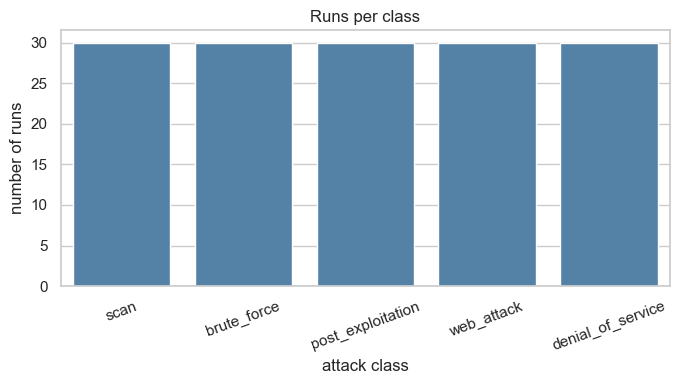

In [4]:
# both datasets contain the SAME runs, so their class balance is identical — show behavioral
balance = df_behav[LABEL_COL].value_counts().reindex(CLASS_ORDER)
print(balance)
print("\ntotal runs:", int(balance.sum()))

# same information as a bar chart
plt.figure(figsize=(7, 4))
sns.countplot(data=df_behav, x=LABEL_COL, order=CLASS_ORDER, color="steelblue")
plt.title("Runs per class")
plt.xlabel("attack class")
plt.ylabel("number of runs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Health check — missing values and duplicates
Confirm there are no empty cells (NaN) and no duplicated rows in either dataset. Both should be zero.

In [5]:
# check both datasets for empty cells and exact-duplicate rows
for name, df in [("behavioral", df_behav), ("full", df_full)]:
    n_missing = int(df.isnull().sum().sum())   # total empty cells in the whole table
    n_dupes   = int(df.duplicated().sum())     # rows that are exact copies of another row
    print(f"{name:11}:  missing cells = {n_missing:>3}   duplicate rows = {n_dupes:>3}")

# if any cells are missing, show which columns; otherwise say it's clean
miss = df_behav.isnull().sum()
miss = miss[miss > 0]
if len(miss):
    print("\ncolumns with missing values (behavioral):")
    print(miss)
else:
    print("\nno missing values in the datasets — good.")

behavioral :  missing cells =   0   duplicate rows =   0
full       :  missing cells =   0   duplicate rows =   0

no missing values in the datasets — good.


## 6. Descriptive statistics
Per-feature summary: count, mean, spread (std), min/max, and the 25/50/75% points (quartiles show how values are spread). This reveals the scale and range of every feature — expect some to run from single digits into the hundreds of thousands.

In [6]:
# .describe() summarises each numeric feature; .T flips it so each FEATURE is a row (easier to read)
# run_id and label are text, so describe() ignores them automatically
df_behav.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_events,150.0,9512.69,22916.85,5.00,32.25,127.00,5782.50,135802.00
duration_sec,150.0,51.64,113.01,0.00,2.25,11.00,78.00,905.00
events_per_sec,150.0,154.72,286.87,0.13,7.62,25.01,99.02,1153.28
inter_event_mean,150.0,0.13,0.64,0.00,0.00,0.03,0.13,7.83
inter_event_std,150.0,0.48,2.35,0.00,0.09,0.21,0.40,28.81
burst_max_per_sec,150.0,773.27,1797.42,5.00,12.00,49.00,581.25,10402.00
burstiness,150.0,3.56,4.45,1.00,1.15,1.99,4.52,44.79
distinct_dest_ports,150.0,475.53,4607.77,1.00,1.00,1.00,2.00,56421.00
distinct_src_ports,150.0,2516.33,6118.00,1.00,4.00,12.00,727.00,33462.00
ports_per_event,150.0,0.12,0.26,0.00,0.00,0.02,0.05,1.00


## 7. How the two datasets relate
`dataset_full` is `dataset_behavioral` plus 9 extra "per-honeypot count" columns. List exactly which columns are the extra ones — this sets up the later question of whether those 9 features actually help.

In [7]:
# find the columns that exist in FULL but not in BEHAVIORAL (the 9 per-honeypot counts)
extra_cols = [c for c in df_full.columns if c not in df_behav.columns]
print("columns in FULL but not in BEHAVIORAL (", len(extra_cols), "extra):")
for c in extra_cols:
    print("   ", c)

# confirm behavioral is fully contained in full (every behavioral column also exists in full)
behav_is_subset = all(c in df_full.columns for c in df_behav.columns)
print("\nevery behavioral column also exists in full:", behav_is_subset)

columns in FULL but not in BEHAVIORAL ( 9 extra):
    n_p0f
    n_suricata
    n_cowrie
    n_dionaea
    n_honeytrap
    n_heralding
    n_tanner
    n_fatt
    n_wordpot

every behavioral column also exists in full: True


## 8. Pick the fingerprint features
Choose the handful of features that each class "lights up" (spotted in the statistics above), and build the real model feature list by dropping `run_id`, `label`, and the two dead download columns. Also defines a small boxplot helper the next cell uses.

In [8]:
# the features that carry the class "fingerprints" (from the stats we looked at)
KEY_FEATURES = [
    "total_events", "events_per_sec", "burst_max_per_sec",
    "distinct_dest_ports", "distinct_src_ports", "frac_on_top_port",
    "n_login_fail", "n_login_success", "n_commands",
    "n_http_events", "distinct_web_paths", "n_suricata_alerts",
]

# the two dead columns we need to drop before modelling (near-constant; see the stats) (all zeros except one)
DROP_COLS = ["n_file_downloads", "any_file_download"]

# the real model feature set = everything except the id column, the label, and the dead cols
model_features = [c for c in df_behav.columns if c not in [ID_COL, LABEL_COL, *DROP_COLS]]
print("model features:", len(model_features), "(expect 32 for behavioral)")

def boxplots_by_class(df, features, ncols=3):
    """One boxplot per feature, split by class, on a symlog y-axis (shows zeros AND huge values)."""
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.2))
    axes = np.array(axes).flatten()
    for ax, feat in zip(axes, features):
        sns.boxplot(data=df, x=LABEL_COL, y=feat,
                    hue=LABEL_COL, hue_order=CLASS_ORDER, order=CLASS_ORDER,
                    palette="Set2", legend=False, fliersize=2, ax=ax)
        ax.set_yscale("symlog")          # symlog can display 0; plain log cannot
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=90, labelsize=8)
    for ax in axes[len(features):]:      # hide leftover empty panels
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()

model features: 32 (expect 32 for behavioral)


## 9. Distribution of each fingerprint feature per class
A boxplot per feature, split by class, so we can see each class sitting in its own range. The y-axis is `symlog` (linear near zero, logarithmic higher up) because the values run from 0 to ~100,000 — on a normal axis it'd collapse to a flat line with a few dots. If a class owns a distinct band for even one feature, that feature separates it.

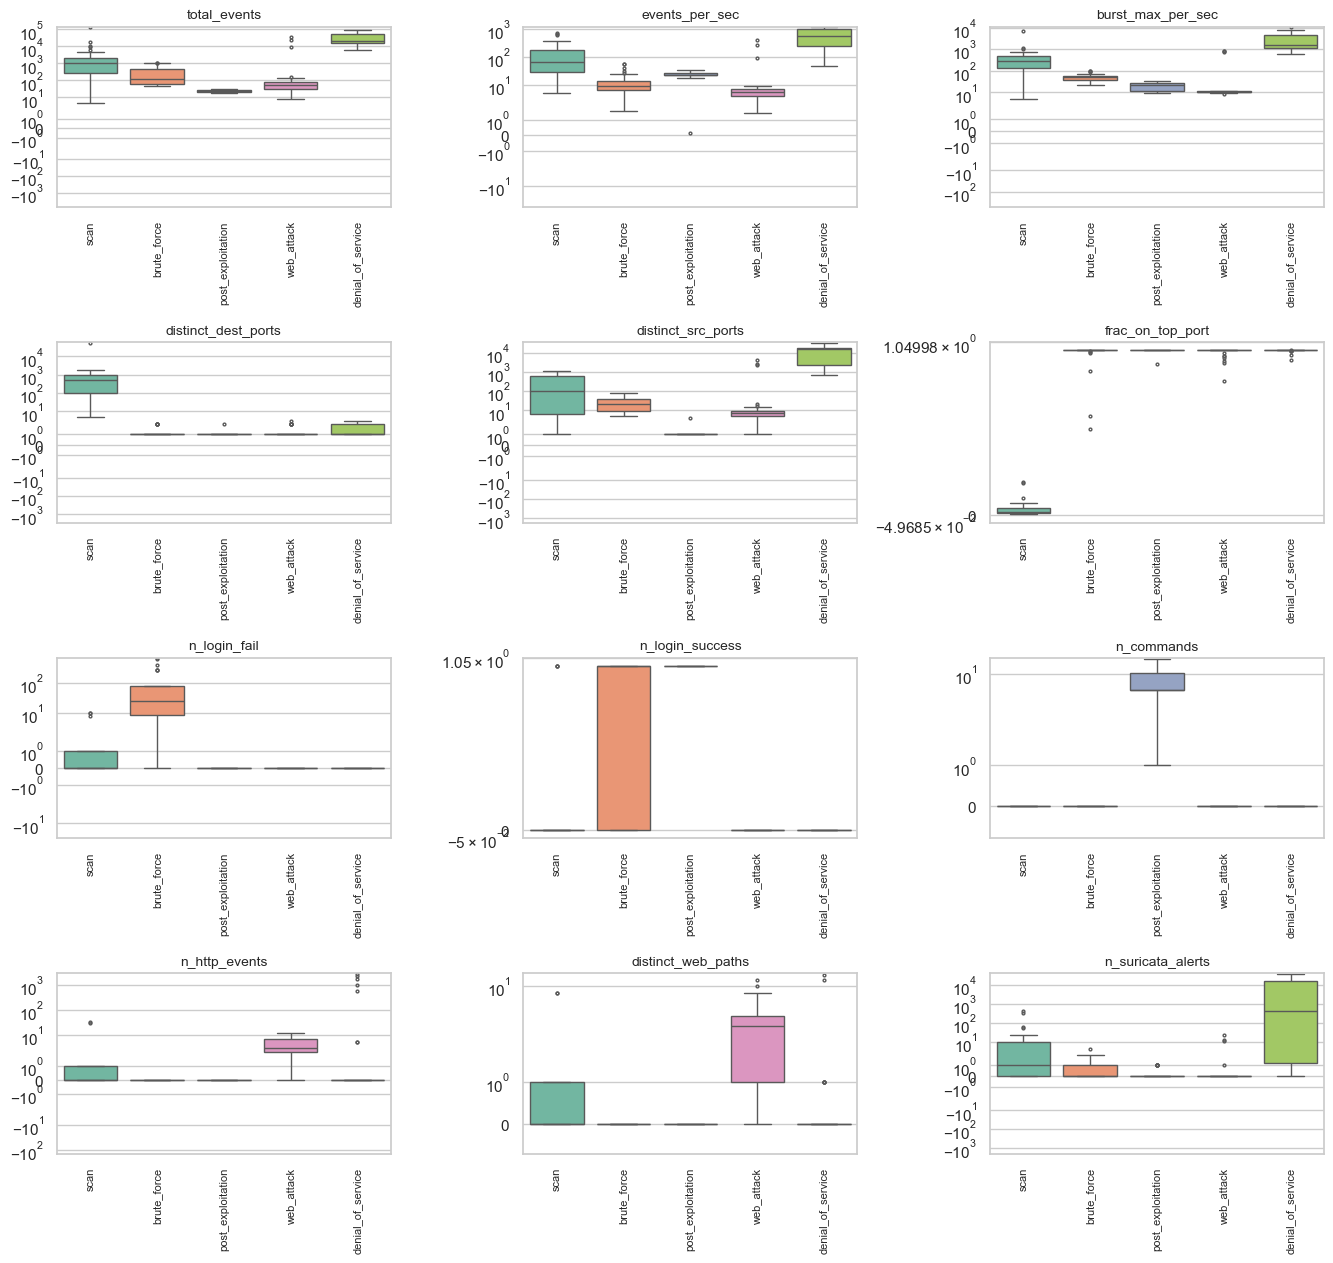

In [9]:
boxplots_by_class(df_behav, KEY_FEATURES)

## 10. Feature correlation
Check which features basically say the same thing. Correlation runs from −1 to +1: dark red means two features rise together, dark blue means one rises as the other falls, near-white means unrelated. Pairs above 0.90 are near-duplicates — worth knowing, since redundant features add little.

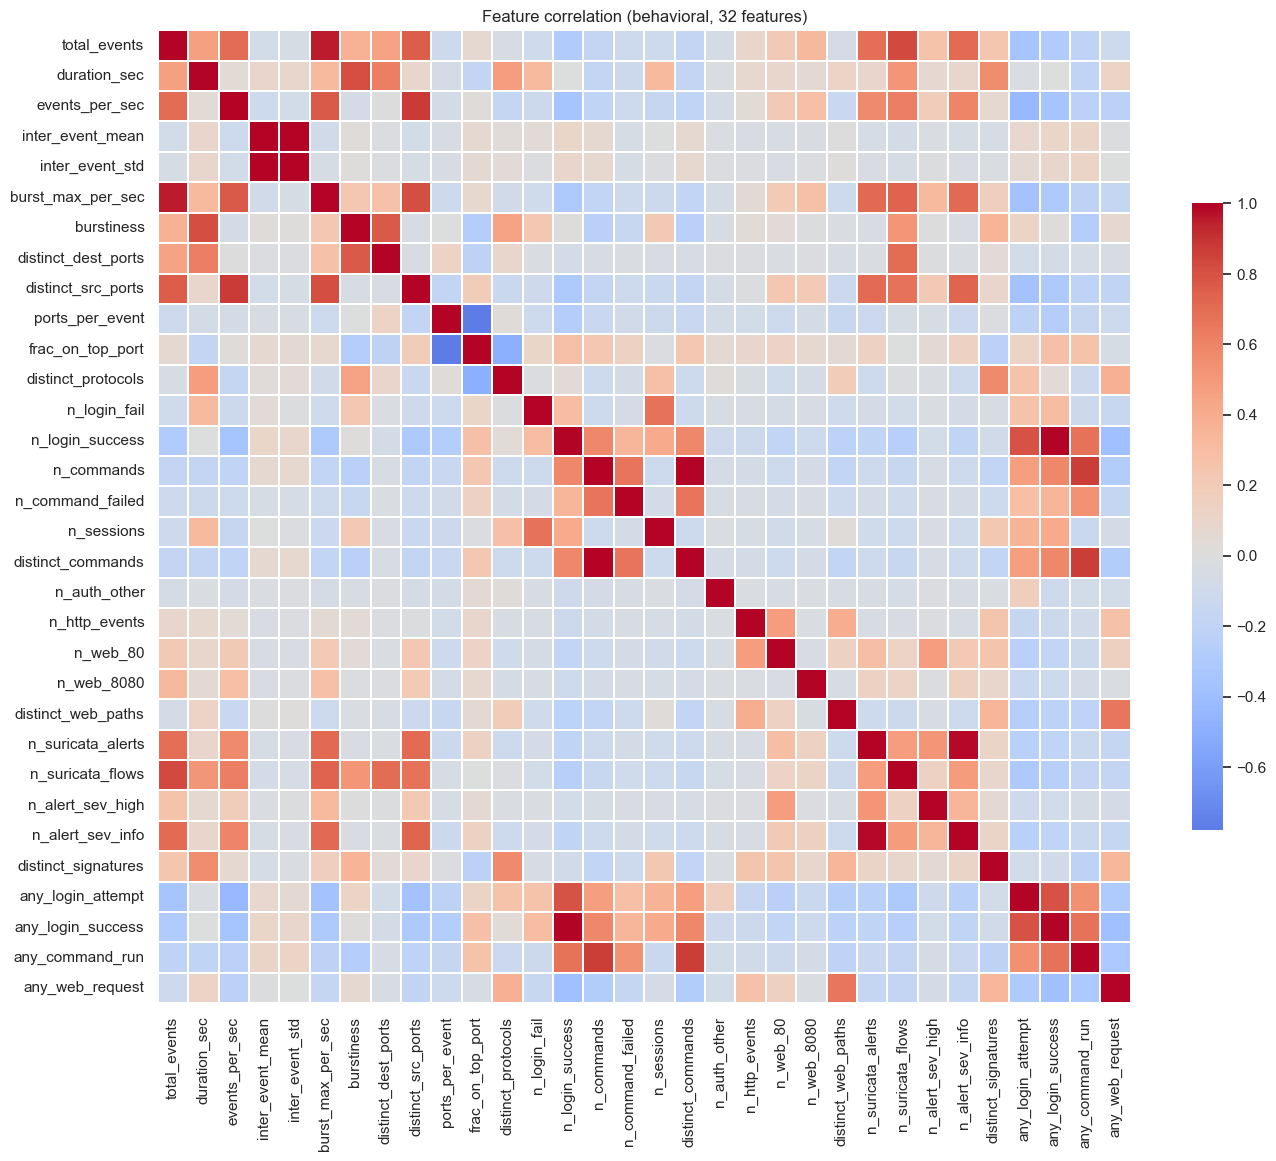

feature pairs with |correlation| > 0.90 (near-duplicates):
   +1.00   n_login_success  &  any_login_success
   +1.00   n_commands  &  distinct_commands
   +0.99   inter_event_mean  &  inter_event_std
   +0.98   n_suricata_alerts  &  n_alert_sev_info
   +0.95   total_events  &  burst_max_per_sec


In [10]:
import itertools

# correlation among the 32 model features
corr = df_behav[model_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation (behavioral, 32 features)")
plt.tight_layout()
plt.show()

# list the strongest pairs (|correlation| > 0.90), ignoring the diagonal
strong = []
for a, b in itertools.combinations(model_features, 2):
    c = corr.loc[a, b]
    if abs(c) > 0.90:
        strong.append((c, a, b))
strong.sort(key=lambda t: abs(t[0]), reverse=True)
print("feature pairs with |correlation| > 0.90 (near-duplicates):")
for c, a, b in strong:
    print(f"   {c:+.2f}   {a}  &  {b}")
if not strong:
    print("   none")

## 11. PCA — the 150 runs squashed to 2D
Compress all 32 features down to 2 axes so the whole dataset fits in one picture, coloured by class. PCA is linear: each axis captures as much of the overall spread as it can, and the % shown is how faithful the 2D view is. Look for whether the five classes land in separate regions.

In [11]:
# one fixed colour per class — distinct and reused across all plots
CLASS_PALETTE = {
    "scan":              "#1f77b4",  # blue
    "brute_force":       "#ff7f0e",  # orange
    "post_exploitation": "#2ca02c",  # green
    "web_attack":        "#d62728",  # red
    "denial_of_service": "#9467bd",  # purple
}

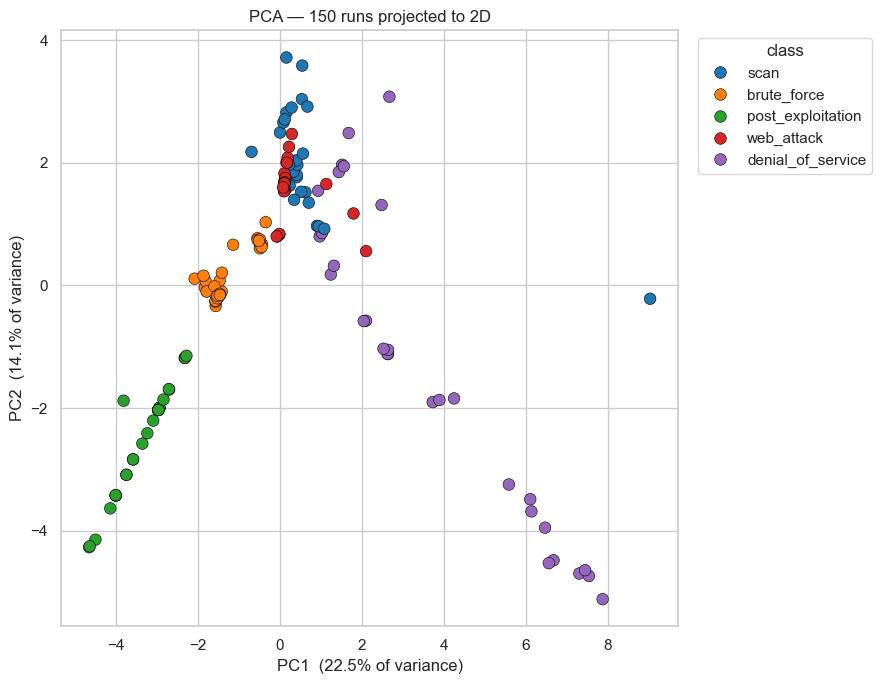

the 2 shown components capture 36.7% of total variance


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_behav[model_features].values
y = df_behav[LABEL_COL].values

# scale ONLY for these 2D pictures (PCA/t-SNE are variance/distance based).
# the Random Forest itself stays UNscaled — trees don't need it.
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_pts = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=pca_pts[:, 0], y=pca_pts[:, 1],
                hue=y, hue_order=CLASS_ORDER, palette=CLASS_PALETTE,
                s=70, edgecolor="black", linewidth=0.4)
plt.xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)")
plt.ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)")
plt.title("PCA — 150 runs projected to 2D")
plt.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"the 2 shown components capture "
      f"{pca.explained_variance_ratio_[:2].sum()*100:.1f}% of total variance")

## 12. t-SNE — 2D again, clusters made clearer
The same squash-to-2D, but t-SNE is nonlinear and tries to keep near neighbours together, so groups usually stand out more sharply. Read it with care: only *which points cluster* is meaningful — the distance between blobs and their sizes are not. Watch where the slow-DoS runs fall relative to `web_attack`.

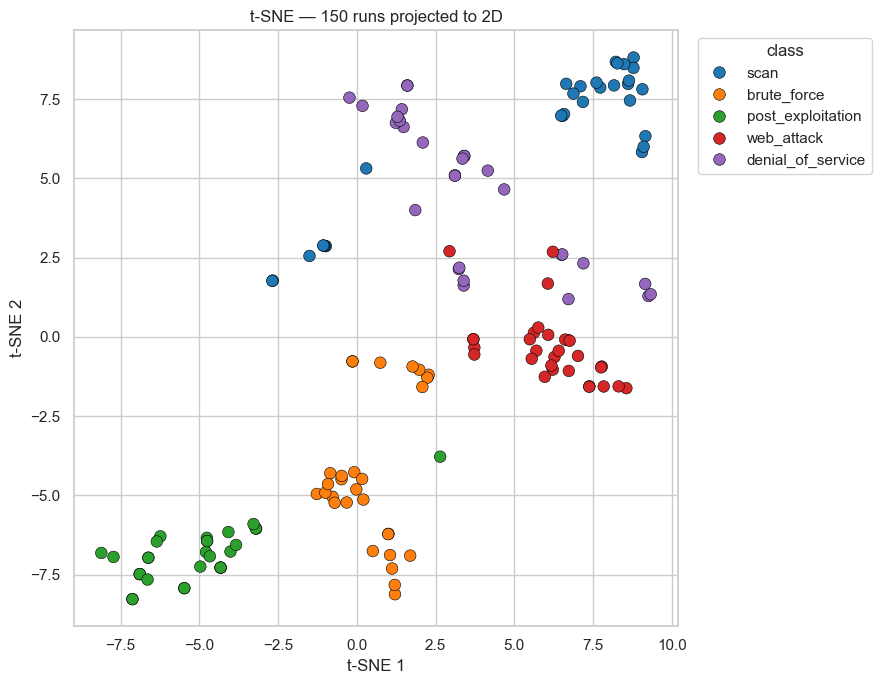

In [13]:
from sklearn.manifold import TSNE

# uses X_scaled from the PCA cell above — run the cells in order
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_STATE)
tsne_pts = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=tsne_pts[:, 0], y=tsne_pts[:, 1],
                hue=y, hue_order=CLASS_ORDER, palette=CLASS_PALETTE,
                s=70, edgecolor="black", linewidth=0.4)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE — 150 runs projected to 2D")
plt.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 13. Build X and y for both datasets
Make the feature matrix (X) and label vector (y) for each dataset — behavioral (32 features) and full (41). Drop run_id, label, and the two dead download columns. Also check both datasets list their runs in the same order, so the labels line up with both.

In [14]:
# behavioral feature matrix (model_features = the 32, from cell 8)
X_behav = df_behav[model_features].values

# full feature matrix: same drops, applied to df_full -> 41 features
model_features_full = [c for c in df_full.columns if c not in [ID_COL, LABEL_COL, *DROP_COLS]]
X_full = df_full[model_features_full].values

# labels and run ids (identical across both datasets)
y       = df_behav[LABEL_COL].values
run_ids = df_behav[ID_COL].values

# safety: the two datasets must have rows in the same order, or y wouldn't match X_full
assert (df_behav[ID_COL].values == df_full[ID_COL].values).all(), "row order differs between datasets!"

print("behavioral X:", X_behav.shape)
print("full       X:", X_full.shape,)
print("labels y    :", y.shape)

behavioral X: (150, 32)
full       X: (150, 41)
labels y    : (150,)


## 14. Cross-validation setup and the tuning helper
Define the 5-fold split (keeps 30-per-class in every fold), the grid of Random Forest settings to try, and a small function that runs GridSearch on a dataset and reports the best settings.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 5-fold stratified cross-validation, shared everywhere for a fair comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# the settings GridSearch will try (every combination = 72)
PARAM_GRID = {
    "n_estimators":      [200, 400],
    "max_depth":         [None, 10, 20],
    "min_samples_leaf":  [1, 2, 4],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}

def tune_rf(X, y, name):
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    grid = GridSearchCV(rf, PARAM_GRID, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)
    print(f"[{name}] best CV accuracy: {grid.best_score_:.4f}")
    print(f"[{name}] best settings   : {grid.best_params_}")
    return grid

## 15. Tune a Random Forest on each dataset
Run GridSearch for behavioral and for full. it's training hundreds of small models to find the best settings for each feature set.

In [16]:
grid_behav = tune_rf(X_behav, y, "behavioral")
print()
grid_full  = tune_rf(X_full,  y, "full")

[behavioral] best CV accuracy: 0.9733
[behavioral] best settings   : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

[full] best CV accuracy: 0.9800
[full] best settings   : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}


## 16. Cross-validation accuracy, with spread
The headline number for each dataset: average accuracy across the 5 folds, plus the ± spread (how much it wobbles fold to fold — smaller means more consistent). Pulled from the GridSearch results, no re-training.

In [17]:
def cv_score_pm(grid):
    i = grid.best_index_
    return grid.cv_results_["mean_test_score"][i], grid.cv_results_["std_test_score"][i]

mb, sb = cv_score_pm(grid_behav)
mf, sf = cv_score_pm(grid_full)
print(f"behavioral (32 feat): CV accuracy = {mb:.4f}  ±  {sb:.4f}")
print(f"full       (41 feat): CV accuracy = {mf:.4f}  ±  {sf:.4f}")

behavioral (32 feat): CV accuracy = 0.9733  ±  0.0249
full       (41 feat): CV accuracy = 0.9800  ±  0.0163


## 17. Confusion matrices — behavioral vs full, side by side
The main comparison. For each dataset, every run is predicted while held out, then pooled into one matrix. Rows = true class, columns = predicted. Perfect = 30 down the diagonal. This is where we see exactly which classes (if any) get confused.

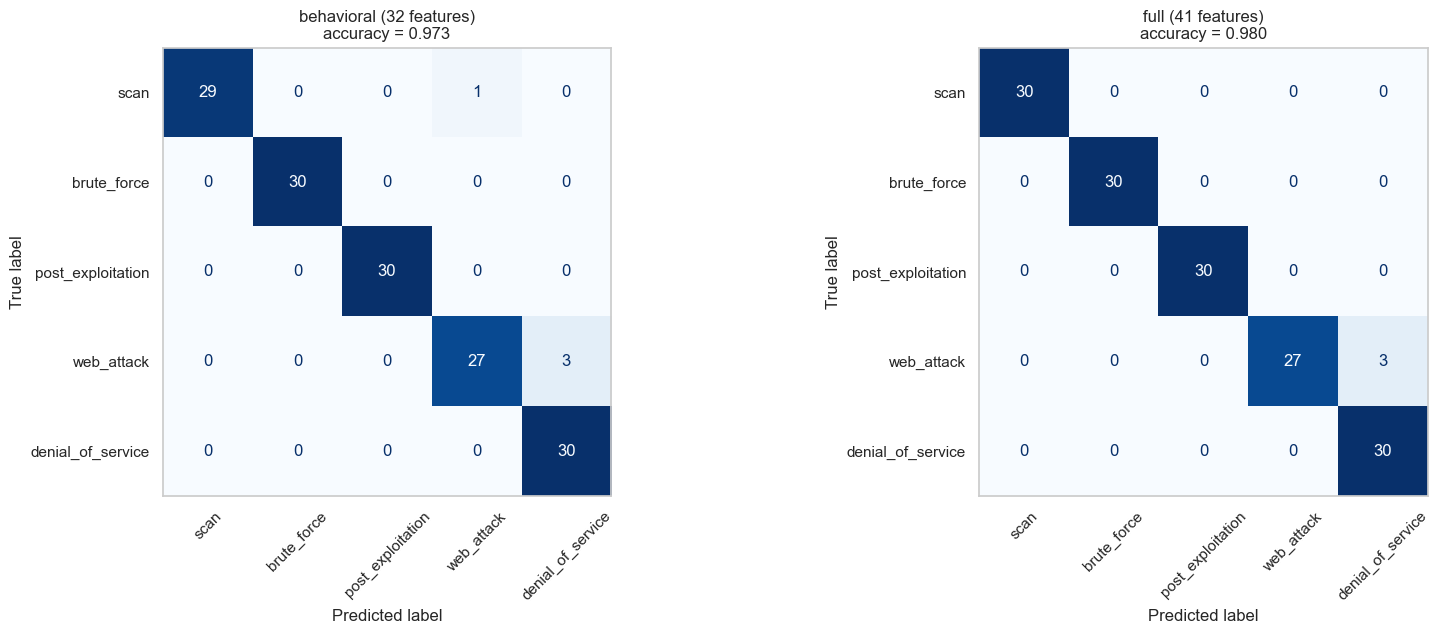

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# out-of-fold predictions using each dataset's best settings
pred_behav = cross_val_predict(grid_behav.best_estimator_, X_behav, y, cv=cv)
pred_full  = cross_val_predict(grid_full.best_estimator_,  X_full,  y, cv=cv)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, pred, name in [(axes[0], pred_behav, "behavioral (32 features)"),
                       (axes[1], pred_full,  "full (41 features)")]:
    cm  = confusion_matrix(y, pred, labels=CLASS_ORDER)
    acc = (pred == y).mean()
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{name}\naccuracy = {acc:.3f}")
    
    # This line forces the gridlines to turn off
    ax.grid(False)

plt.tight_layout()
plt.show()

## 18. Per-class report for the behavioral model
Break the behavioral result down by class: precision (how trustworthy each "X" call is), recall (how many real X it caught), and F1 (the two combined). This shows whether any single class — likely denial_of_service or web_attack — is weaker than the rest.

In [19]:
from sklearn.metrics import classification_report
print("=== behavioral — per-class report (cross-validated over all 150 runs) ===\n")
print(classification_report(y, pred_behav, labels=CLASS_ORDER, digits=3))

=== behavioral — per-class report (cross-validated over all 150 runs) ===

                   precision    recall  f1-score   support

             scan      1.000     0.967     0.983        30
      brute_force      1.000     1.000     1.000        30
post_exploitation      1.000     1.000     1.000        30
       web_attack      0.964     0.900     0.931        30
denial_of_service      0.909     1.000     0.952        30

         accuracy                          0.973       150
        macro avg      0.975     0.973     0.973       150
     weighted avg      0.975     0.973     0.973       150



## 19. Which runs did the behavioral model get wrong?
List every misclassified run by its ID, with its true class and what the model guessed instead.

In [20]:
mask = pred_behav != y
print(f"behavioral misclassified: {mask.sum()} of {len(y)} runs\n")
for rid, true_c, pred_c in sorted(zip(run_ids[mask], y[mask], pred_behav[mask])):
    print(f"   {rid}:  true = {true_c:18}  ->  predicted = {pred_c}")
if mask.sum() == 0:
    print("   none — every run classified correctly.")

behavioral misclassified: 4 of 150 runs

   S001:  true = scan                ->  predicted = web_attack
   W001:  true = web_attack          ->  predicted = denial_of_service
   W002:  true = web_attack          ->  predicted = denial_of_service
   W003:  true = web_attack          ->  predicted = denial_of_service


## 20. Verdict — do the 9 honeypot-count features help?
Put the two datasets side by side on accuracy and macro-F1 (F1 averaged over the 5 classes). If full isn't clearly better than behavioral, the sensor-count features add nothing — meaning the model separates attacks by their behavior, not by which honeypot logged them. That's the thesis point, and it's why we deploy the behavioral model.

In [21]:
from sklearn.metrics import f1_score
print(f"{'dataset':20}{'accuracy':>10}{'macro-F1':>11}")
print("-" * 41)
for name, pred in [("behavioral (32)", pred_behav), ("full (41)", pred_full)]:
    acc = (pred == y).mean()
    mf1 = f1_score(y, pred, average="macro")
    print(f"{name:20}{acc:>10.3f}{mf1:>11.3f}")

dataset               accuracy   macro-F1
-----------------------------------------
behavioral (32)          0.973      0.973
full (41)                0.980      0.980


## 21. A quick reference: the class-average feature values
Build a small table of each class's mean for every feature, so the next cell can show a misclassified run beside "what a typical run of each class looks like". Just a lookup table — no modelling.

In [22]:
# mean of every feature within each class (rows = class, cols = feature)
class_means = df_behav.groupby(LABEL_COL)[model_features].mean().reindex(CLASS_ORDER)
class_means.round(1)

,total_events,duration_sec,events_per_sec,inter_event_mean,inter_event_std,burst_max_per_sec,burstiness,distinct_dest_ports,distinct_src_ports,ports_per_event,frac_on_top_port,distinct_protocols,n_login_fail,n_login_success,n_commands,n_command_failed,n_sessions,distinct_commands,n_auth_other,n_http_events,n_web_80,n_web_8080,distinct_web_paths,n_suricata_alerts,n_suricata_flows,n_alert_sev_high,n_alert_sev_info,distinct_signatures,any_login_attempt,any_login_success,any_command_run,any_web_request
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
scan,6869.1,91.9,146.6,0.0,0.1,548.9,5.7,2372.8,317.5,0.5,0.0,5.3,1.2,0.1,0.0,0.0,4.5,0.0,0.2,2.4,27.5,24.4,0.8,31.6,2678.7,17.8,13.8,3.2,0.3,0.1,0.0,0.3
brute_force,295.0,49.2,14.2,0.1,0.3,49.3,5.5,1.2,25.4,0.0,1.0,2.3,99.6,0.7,0.0,0.0,14.3,0.0,3.7,0.0,0.0,0.0,0.0,0.6,10.4,0.3,0.3,0.5,1.0,0.7,0.0,0.0
post_exploitation,24.3,6.4,23.5,0.3,1.1,19.8,1.2,1.0,1.1,0.0,1.0,2.1,0.0,1.0,7.4,0.5,1.0,7.4,0.0,0.0,0.0,0.0,0.0,0.2,0.1,0.0,0.2,0.2,1.0,1.0,1.0,0.0
web_attack,2410.6,20.4,29.6,0.2,0.7,86.3,1.6,1.3,319.2,0.0,1.0,2.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.1,1129.7,1280.8,3.4,1.6,202.4,0.1,1.5,0.6,0.0,0.0,0.0,0.9
denial_of_service,37964.5,90.3,559.7,0.0,0.2,3162.1,3.8,1.4,11918.5,0.0,1.0,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,281.1,7359.6,5107.5,1.0,8670.0,10127.4,777.3,7892.8,3.6,0.0,0.0,0.0,0.2


## 22. Why did each misclassified run cross the boundary?
For every run the model got wrong, show its feature values beside the average of its TRUE class and its PREDICTED class. Values sitting closer to the predicted class's column explain why it was misread. Errors are read automatically from the cross-validated predictions.

In [31]:
# the features most useful for explaining the confusions we see
EXPLAIN_FEATURES = [
    "total_events", "duration_sec", "burst_max_per_sec",
    "distinct_dest_ports", "distinct_src_ports", "frac_on_top_port",
    "n_login_fail", "n_login_success", "n_auth_other", "n_commands",
    "n_web_80", "n_web_8080", "n_http_events", "distinct_web_paths",
    "n_suricata_flows", "n_suricata_alerts",
]

# class-average table (mean of each feature per class)
class_means = df_behav.groupby(LABEL_COL)[EXPLAIN_FEATURES].mean()

# find the misclassified runs from the cross-validated predictions
mask = pred_behav != y
wrong = list(zip(run_ids[mask], y[mask], pred_behav[mask]))

if not wrong:
    print("No misclassified runs — nothing to explain.")
else:
    print(f"{mask.sum()} misclassified run(s):",
          ", ".join(f"{r}({t}->{p})" for r, t, p in wrong), "\n")
    for rid, true_c, pred_c in sorted(wrong):
        row = df_behav.loc[df_behav[ID_COL] == rid, EXPLAIN_FEATURES].iloc[0]
        table = pd.DataFrame({
            rid:              row,
            f"avg[{true_c}]": class_means.loc[true_c],
            f"avg[{pred_c}]": class_means.loc[pred_c],
        })
        print(f"===== {rid}:  truly {true_c}  ->  predicted {pred_c} =====")
        display(table.round(1))
        print()

4 misclassified run(s): S001(scan->web_attack), W001(web_attack->denial_of_service), W002(web_attack->denial_of_service), W003(web_attack->denial_of_service) 

===== S001:  truly scan  ->  predicted web_attack =====


,S001,avg[scan],avg[web_attack]
total_events,5.0,6869.1,2410.6
duration_sec,0.0,91.9,20.4
burst_max_per_sec,5.0,548.9,86.3
distinct_dest_ports,5.0,2372.8,1.3
distinct_src_ports,1.0,317.5,319.2
frac_on_top_port,0.2,0.0,1.0
n_login_fail,0.0,1.2,0.0
n_login_success,0.0,0.1,0.0
n_auth_other,0.0,0.2,0.0
n_commands,0.0,0.0,0.0



===== W001:  truly web_attack  ->  predicted denial_of_service =====


,W001,avg[web_attack],avg[denial_of_service]
total_events,24219.0,2410.6,37964.5
duration_sec,92.0,20.4,90.3
burst_max_per_sec,821.0,86.3,3162.1
distinct_dest_ports,1.0,1.3,1.4
distinct_src_ports,2731.0,319.2,11918.5
frac_on_top_port,1.0,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0



===== W002:  truly web_attack  ->  predicted denial_of_service =====


,W002,avg[web_attack],avg[denial_of_service]
total_events,37742.0,2410.6,37964.5
duration_sec,96.0,20.4,90.3
burst_max_per_sec,788.0,86.3,3162.1
distinct_dest_ports,2.0,1.3,1.4
distinct_src_ports,4359.0,319.2,11918.5
frac_on_top_port,1.0,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0



===== W003:  truly web_attack  ->  predicted denial_of_service =====


,W003,avg[web_attack],avg[denial_of_service]
total_events,8842.0,2410.6,37964.5
duration_sec,95.0,20.4,90.3
burst_max_per_sec,704.0,86.3,3162.1
distinct_dest_ports,3.0,1.3,1.4
distinct_src_ports,2283.0,319.2,11918.5
frac_on_top_port,0.8,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0


## 22. Feature importance — what the model actually relies on
Two views. Left: the Random Forest's built-in importance (how much each feature helped its splits). Right: permutation importance (shuffle one feature's values and see how much accuracy drops — a more trustworthy measure of what the model truly needs). We expect the "fingerprint" features to dominate.

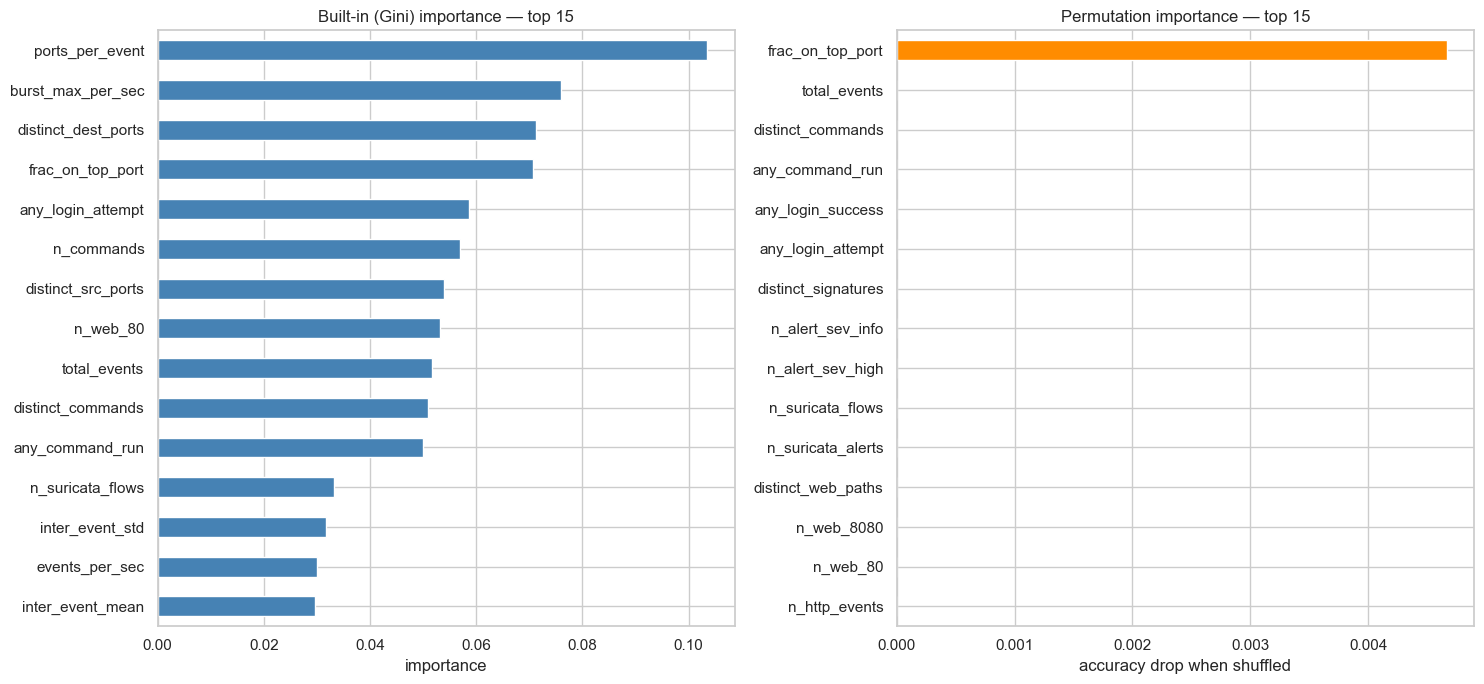

top 10 by permutation importance:
frac_on_top_port       0.0047
total_events           0.0000
distinct_commands      0.0000
any_command_run        0.0000
any_login_success      0.0000
any_login_attempt      0.0000
distinct_signatures    0.0000
n_alert_sev_info       0.0000
n_alert_sev_high       0.0000
n_suricata_flows       0.0000
dtype: float64


In [24]:
from sklearn.inspection import permutation_importance

# fit the tuned behavioral forest on all 150 rows to inspect it
rf_behav = grid_behav.best_estimator_.fit(X_behav, y)

# built-in (Gini) importance
gini = pd.Series(rf_behav.feature_importances_, index=model_features).sort_values(ascending=False)

# permutation importance (shuffle each feature, measure accuracy drop; averaged over repeats)
perm = permutation_importance(rf_behav, X_behav, y, n_repeats=20,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
gini.head(15).iloc[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Built-in (Gini) importance — top 15"); axes[0].set_xlabel("importance")
perm.head(15).iloc[::-1].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Permutation importance — top 15"); axes[1].set_xlabel("accuracy drop when shuffled")
plt.tight_layout(); plt.show()

print("top 10 by permutation importance:")
print(perm.head(10).round(4))